# 03 · Model selection with cross-validation and Optuna

Protocol
1. Hold out 20 % as a **test set** (stratified by price decile). It is not touched in this notebook.
2. On the remaining 80 %, compare all models with **5-fold CV** (folds stratified by price decile).
3. Tune each family with **Optuna (TPE + median pruning)**; the objective is the mean CV MAE on log-price.
4. Report **mean ± std across folds**, so differences smaller than the fold noise are not over-read.

Results are produced by `python -m car_price.train` (see README).

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from car_price.config import load_config, resolve
from car_price.data import TARGET, clean, load_dataset

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 110, "savefig.bbox": "tight"})
cfg = load_config()
FIG = resolve(cfg, "figures"); FIG.mkdir(parents=True, exist_ok=True)

import json
import optuna
from car_price.evaluate import make_folds, split_train_test
res = resolve(cfg, "results")
lb = pd.read_csv(res / "cv_leaderboard.csv")
lb["label"] = lb.model + np.where(lb.tuned, " (tuned)", " (default)")

## Leaderboard (CV on the 80 % training portion)

In [2]:
show = lb[["label", "mae_mean", "mae_std", "mape_mean", "r2_mean", "mae_log_mean", "mae_log_std", "fit_time_mean"]].copy()
show["MAE (€)"] = show.mae_mean.round(0).astype(int).astype(str) + " ± " + show.mae_std.round(0).astype(int).astype(str)
show["MAPE"] = (show.mape_mean * 100).round(1).astype(str) + " %"
show["R²"] = show.r2_mean.round(3)
show["MAE log-price"] = show.mae_log_mean.round(4).astype(str) + " ± " + show.mae_log_std.round(4).astype(str)
show["fit s/fold"] = show.fit_time_mean.round(1)
show.set_index("label")[["MAE (€)", "MAPE", "R²", "MAE log-price", "fit s/fold"]]

,MAE (€),MAPE,R²,MAE log-price,fit s/fold
label,,,,,
lgbm (tuned),2124 ± 160,12.0 %,0.658,0.1131 ± 0.0011,390.2
xgb (tuned),2129 ± 147,12.1 %,0.661,0.1136 ± 0.001,56.6
rf (tuned),2162 ± 147,12.6 %,0.654,0.1184 ± 0.0012,82.8
catboost (tuned),2409 ± 164,13.2 %,0.641,0.1251 ± 0.0012,145.1
poly_ridge (tuned),3342 ± 205,18.1 %,0.540,0.1691 ± 0.0016,2.4
ridge (tuned),3819 ± 207,20.9 %,0.513,0.193 ± 0.0019,2.1
elasticnet (tuned),3837 ± 207,20.8 %,0.511,0.193 ± 0.0019,6.7
dummy (default),10714 ± 203,94.6 %,-0.030,0.627 ± 0.0016,1.2


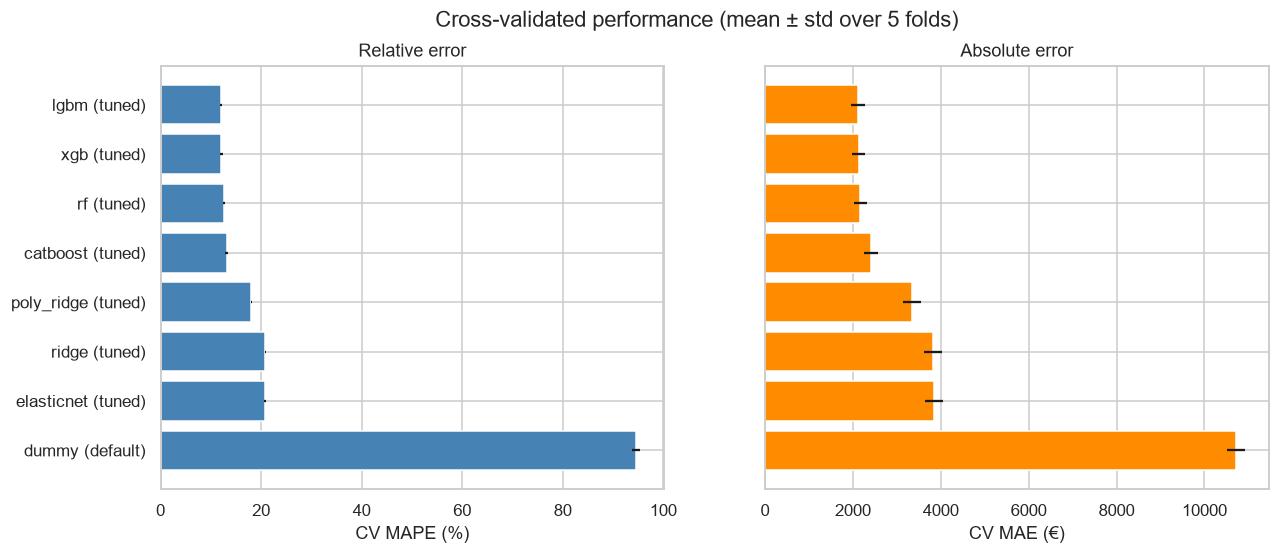

In [3]:
d = lb.sort_values("mae_log_mean", ascending=False)
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
axes[0].barh(d.label, d.mape_mean * 100, xerr=d.mape_std * 100, color="steelblue"); axes[0].set(xlabel="CV MAPE (%)", title="Relative error")
axes[1].barh(d.label, d.mae_mean, xerr=d.mae_std, color="darkorange"); axes[1].set(xlabel="CV MAE (€)", title="Absolute error")
fig.suptitle("Cross-validated performance (mean ± std over 5 folds)")
plt.show()

## What Optuna found
Optimisation history (each dot is a trial; the line is the running best) and which hyper-parameters mattered.

In [4]:
db = f"sqlite:///{resolve(cfg, 'optuna_db').as_posix()}"
optuna.logging.set_verbosity(optuna.logging.WARNING)
studies = {}
for m in lb[lb.tuned].model:
    try: studies[m] = optuna.load_study(study_name=f"car_price_{m}", storage=db)
    except KeyError: pass
best_params = {r.model: json.loads(r.params) for r in lb[lb.tuned].itertuples()}
pd.DataFrame({m: pd.Series(p) for m, p in best_params.items()}).T

,alpha,colsample_bytree,depth,iterations,l1_ratio,l2_leaf_reg,learning_rate,max_depth,max_features,min_child_samples,min_child_weight,min_samples_leaf,n_estimators,num_leaves,random_strength,reg_alpha,reg_lambda,subsample,subsample_freq
ridge,662.667464,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
elasticnet,0.000859,NaN,NaN,NaN,0.318839,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
poly_ridge,191.279139,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
rf,NaN,NaN,NaN,NaN,NaN,NaN,NaN,28.0,0.756693,NaN,NaN,1.0,300.0,NaN,NaN,NaN,NaN,NaN,NaN
xgb,NaN,0.763705,NaN,NaN,NaN,NaN,0.044999,12.0,NaN,NaN,19.0,NaN,1400.0,NaN,NaN,0.101411,0.583346,0.925754,NaN
lgbm,NaN,0.700069,NaN,NaN,NaN,NaN,0.034519,NaN,NaN,20.0,NaN,NaN,1900.0,192.0,NaN,0.006731,5.205129,0.839199,1.0
catboost,NaN,NaN,7.0,600.0,NaN,1.142091,0.075272,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.405429,NaN,NaN,NaN,NaN


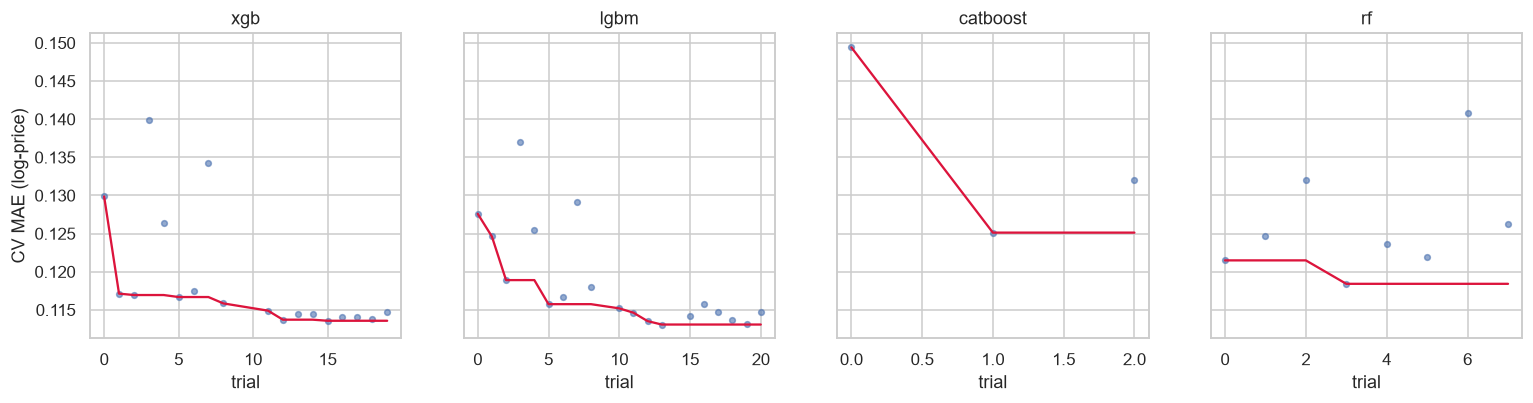

In [5]:
boost = [m for m in ["xgb", "lgbm", "catboost", "rf"] if m in studies]
fig, axes = plt.subplots(1, len(boost), figsize=(4.2 * len(boost), 3.6), sharey=True)
axes = np.atleast_1d(axes)
for ax, m in zip(axes, boost):
    t = studies[m].trials_dataframe()
    t = t[t.state == "COMPLETE"]
    ax.scatter(t.number, t.value, s=14, alpha=.6); ax.plot(t.number, t.value.cummin(), color="crimson")
    ax.set(title=m, xlabel="trial", ylabel="CV MAE (log-price)" if ax is axes[0] else "")
plt.show()

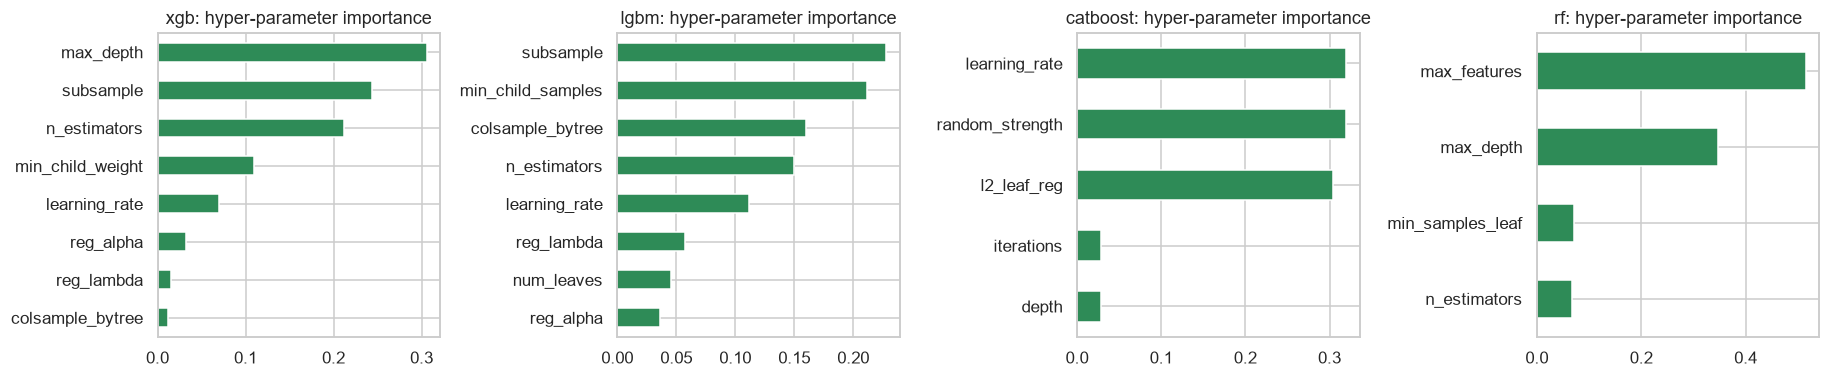

In [6]:
fig, axes = plt.subplots(1, len(boost), figsize=(4.2 * len(boost), 3.6))
axes = np.atleast_1d(axes)
for ax, m in zip(axes, boost):
    imp = optuna.importance.get_param_importances(studies[m])
    pd.Series(imp).sort_values().plot.barh(ax=ax, color="seagreen"); ax.set_title(f"{m}: hyper-parameter importance")
fig.tight_layout()
plt.show()

## Tuned vs default: how much did tuning buy?

In [7]:
pv = lb.pivot(index="model", columns="tuned", values="mae_log_mean").rename(columns={False: "default", True: "tuned"})
if {"default", "tuned"} <= set(pv.columns):
    pv["improvement"] = (1 - pv.tuned / pv.default) * 100
    display(pv.dropna().round(4).style.format({"improvement": "{:.1f} %"}))

tuned,default,tuned,improvement
model,,,


## Learning curve of the best model
Does more data still help (variance-limited) or has the model plateaued (bias-limited)?

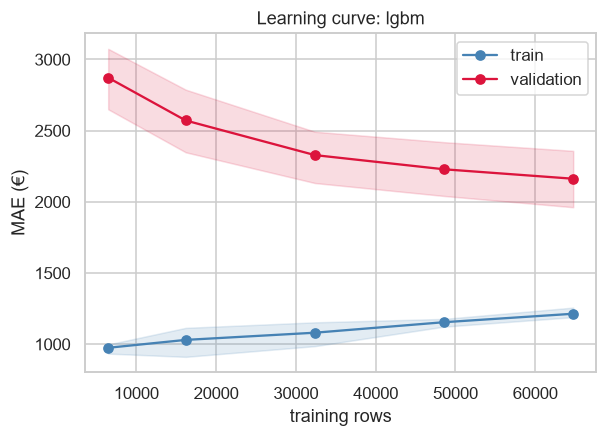

In [8]:
from sklearn.model_selection import learning_curve
from car_price.data import clean
from car_price.pipelines import build_pipeline
raw, source = load_dataset(cfg)
train, _ = split_train_test(clean(raw, cfg), cfg)            # the test half is discarded
X, y = train.drop(columns=TARGET), train[TARGET]
best = lb.sort_values("mae_log_mean").iloc[0]
pipe = build_pipeline(best.model, json.loads(best.params), cfg["seed"], cfg["cleaning"]["reference_year"])
sizes, tr, va = learning_curve(pipe, X, y, train_sizes=[.1, .25, .5, .75, 1.0], cv=make_folds(y, cfg)[:3],
                               scoring="neg_mean_absolute_error", n_jobs=1)
fig, ax = plt.subplots(figsize=(6, 4))
for s, lab, col in [(-tr, "train", "steelblue"), (-va, "validation", "crimson")]:
    ax.plot(sizes, s.mean(1), "o-", label=lab, color=col); ax.fill_between(sizes, s.min(1), s.max(1), alpha=.15, color=col)
ax.set(xlabel="training rows", ylabel="MAE (€)", title=f"Learning curve: {best.model}"); ax.legend()
plt.show()